In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.metrics import (
    roc_auc_score, precision_score, 
    recall_score, f1_score, 
    matthews_corrcoef,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from utils import recall_at_top_n_percent

import mlflow
import mlflow.xgboost

import warnings
import argparse
import logging
from typing import *

import matplotlib.pyplot as plt
import seaborn as sns

from namespaces import DA

/home/mai/notebooks/final_thesis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logging.basicConfig(level=logging.WARN)
logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore")

In [3]:
os.chdir('/home/mai/notebooks/final_thesis/')
os.getcwd()

'/home/mai/notebooks/final_thesis'

In [4]:
# search for the best run
experiment_name = 'xgb_optuna_tuning'
metric_name = ['auc', 'mcc']

exp = mlflow.get_experiment_by_name(experiment_name)
runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    order_by=[
        f"metrics.{metric_name[0]} DESC",
        f"metrics.{metric_name[1]} DESC"
    ],
    max_results=1
)

best_run = runs.iloc[0]
best_run_id = best_run.run_id

print("Best run:", best_run_id)
print("Best metric - AUC:", best_run[f"metrics.{metric_name[0]}"], "MCC:", best_run[f"metrics.{metric_name[1]}"])

Best run: 038d329eadc24327a15f3b675c22b350
Best metric - AUC: 0.7202219963827541 MCC: 0.06946631961361782


In [5]:
# load best model
model = mlflow.xgboost.load_model(f"runs:/{best_run.run_id}/model")

In [6]:
model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",[0.3817845]
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

In [11]:
def load_data(data_path):
    data = np.load(os.path.join(data_path, 'dgraphfin_processed.npz'))
    # train
    X_train = pd.DataFrame(data['x_train'])
    y_train = pd.DataFrame(data['y_train'])
    # val
    X_val = pd.DataFrame(data['x_val'])
    y_val = pd.DataFrame(data['y_val'])
    # test
    X_test = pd.DataFrame(data['x_test'])
    y_test = pd.DataFrame(data['y_test'])
    return X_train, X_val, X_test, y_train, y_val, y_test


def eval_metrics(actual, pred_labels, pred_probas):
    auc = roc_auc_score(actual, pred_probas)
    recall = recall_score(actual, pred_labels)
    precision = precision_score(actual, pred_labels)
    f1 = recall_score(actual, pred_labels)
    matthews_corr = matthews_corrcoef(actual, pred_labels)
    recall_at_1_percent = recall_at_top_n_percent(actual, pred_probas, n_percent=1)
    return auc, recall, precision, f1, matthews_corr, recall_at_1_percent

In [8]:
_, X_val, X_test, _, y_val, y_test = load_data(DA.paths.output_data_ml)

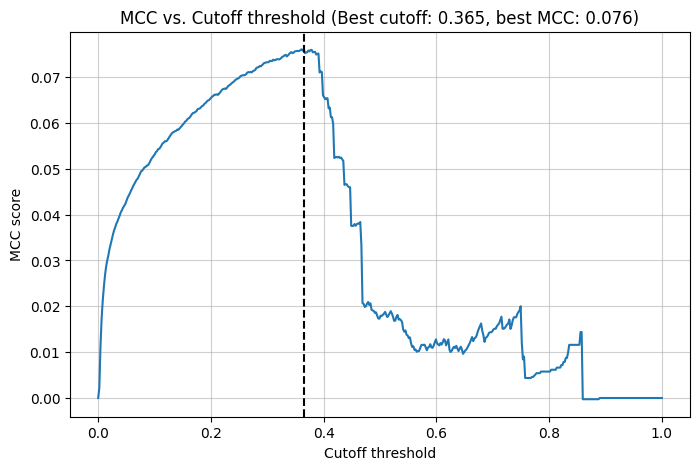

In [9]:
# cutoff selection to maximize mcc
y_prob = model.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0, 1, 500)
mcc_scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    mcc_scores.append(matthews_corrcoef(y_val, y_pred))

best_idx = np.argmax(mcc_scores)
best_threshold = thresholds[best_idx]
best_mcc = mcc_scores[best_idx]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, mcc_scores)
plt.axvline(best_threshold, ls='--', color='k')
plt.title(f"MCC vs. Cutoff threshold (Best cutoff: {best_threshold:.3f}, best MCC: {best_mcc:.3f})")
plt.xlabel("Cutoff threshold")
plt.ylabel("MCC score")
plt.grid(True, axis='both', alpha=.6)
plt.show()

In [12]:
# use selected threshold on test set
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

# eval
auc, recall, precision, f1, mcc, recall_at_1 = eval_metrics(y_test, y_pred, y_prob)

In [13]:
print(f'AUC: {auc:.4f}')
print(f'Recall: {recall:.4f}')
print(f'Precision: {precision:.4f}')
print(f'F1: {f1:.4f}')
print(f'MCC: {mcc:.4f}')
print(f'Recall at 1%: {recall_at_1:.4f}')

AUC: 0.7036
Recall: 0.8267
Precision: 0.0212
F1: 0.8267
MCC: 0.0756
Recall at 1%: 0.0202


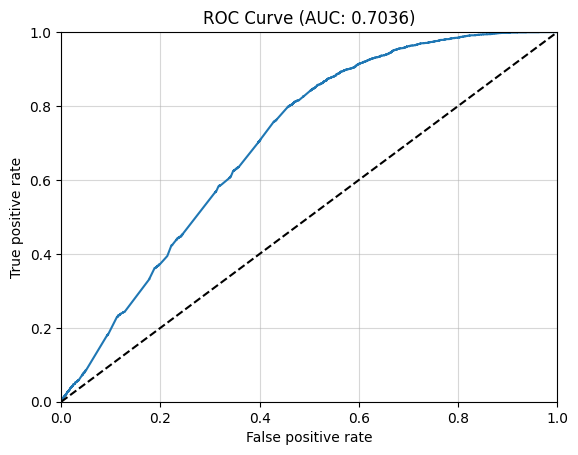

In [14]:
# examine ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], ls='--', color='k')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"ROC Curve (AUC: {auc:.4f})")
plt.grid(True, axis='both', alpha=0.5)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

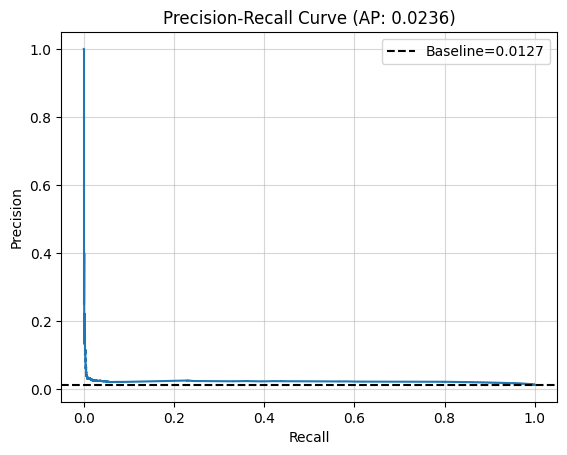

In [15]:
# examine precision recall curve
pr, rc, thresholds = precision_recall_curve(y_test, y_prob)
ap_value = average_precision_score(y_test, y_prob)
baseline = np.mean(y_test)

plt.figure()
plt.plot(rc, pr)
plt.axhline(baseline, linestyle="--", label=f"Baseline={baseline:.4f}", color='k')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP: {ap_value:.4f})")
plt.grid(True, axis='both', alpha=0.5)
# plt.xlim(0, 1)
# plt.ylim(0, 1)
plt.legend()
plt.show()

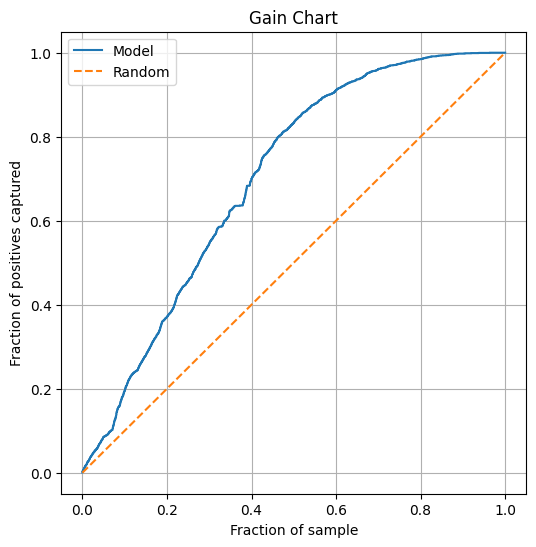

In [16]:
# examine gain and lift charts
gl = pd.DataFrame({
    'y_test': y_test.values.ravel(),
    'y_prob': y_prob
})

gl = gl.sort_values(by='y_prob', ascending=False).reset_index(drop=True)

gl['cum_positives'] = gl['y_test'].cumsum()
gl['gain'] = gl['cum_positives'] / gl['y_test'].sum()
gl['samples_frac'] = np.arange(1, len(gl)+1) / len(gl)

plt.figure(figsize=(6, 6))
plt.plot(gl["samples_frac"], gl["gain"], label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")  # random baseline
plt.xlabel("Fraction of sample")
plt.ylabel("Fraction of positives captured")
plt.title("Gain Chart")
plt.legend()
plt.grid(True)
plt.show()

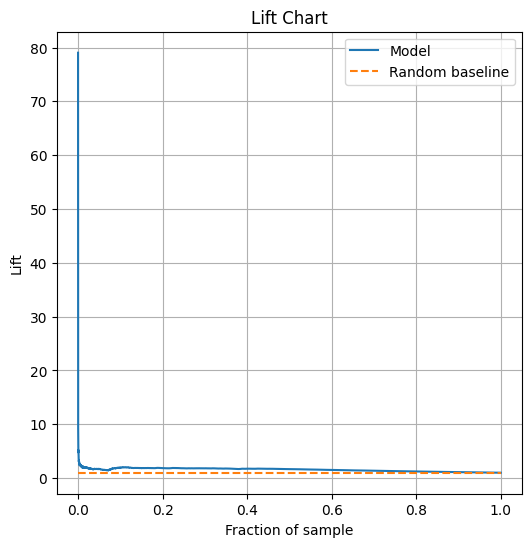

In [17]:
# examine lift chart
gl['lift'] = gl['gain'] / gl['samples_frac']

plt.figure(figsize=(6, 6))
plt.plot(gl["samples_frac"], gl["lift"], label="Model")
plt.plot([0, 1], [1, 1], linestyle="--", label="Random baseline")  # baseline lift = 1
plt.xlabel("Fraction of sample")
plt.ylabel("Lift")
plt.title("Lift Chart")
plt.legend()
plt.grid(True)
plt.show()

<Axes: ylabel='Density'>

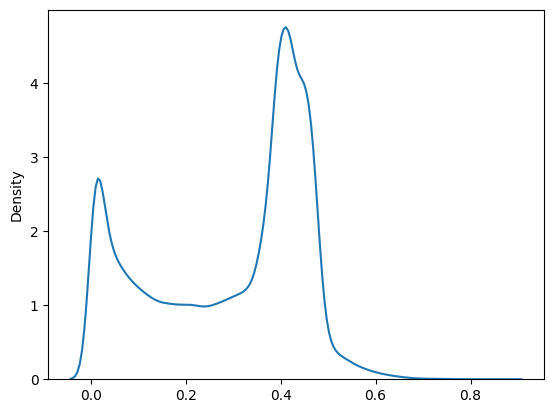

In [18]:
sns.kdeplot(y_prob)

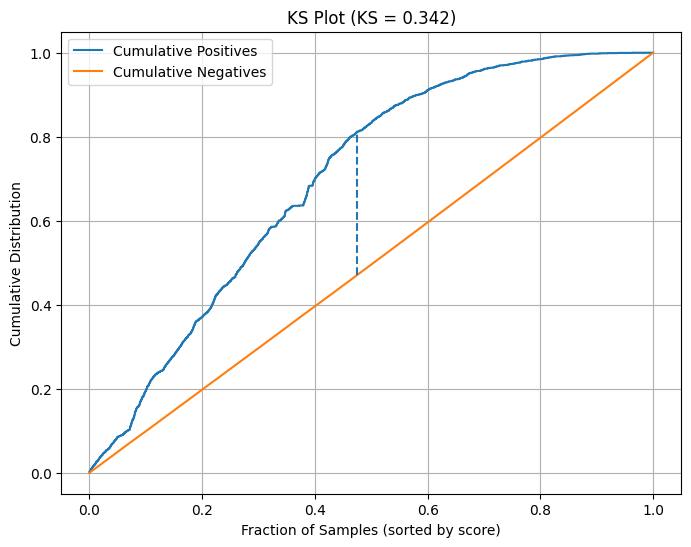

In [19]:
# KS plot
# negatives indicator
gl['neg'] = 1 - gl['y_test']

# cumulative negatives
gl['cum_negatives'] = gl['neg'].cumsum()

# normalize both cumulative curves
gl['cum_pos_rate'] = gl['cum_positives'] / gl['cum_positives'].iloc[-1]
gl['cum_neg_rate'] = gl['cum_negatives'] / gl['cum_negatives'].iloc[-1]

# KS distance
gl['ks'] = gl['cum_pos_rate'] - gl['cum_neg_rate']

ks_value = gl['ks'].abs().max()
ks_idx = gl['ks'].abs().idxmax()

plt.figure(figsize=(8,6))

plt.plot(gl['samples_frac'], gl['cum_pos_rate'], label='Cumulative Positives')
plt.plot(gl['samples_frac'], gl['cum_neg_rate'], label='Cumulative Negatives')

# KS vertical line
plt.vlines(gl.loc[ks_idx, 'samples_frac'],
           gl.loc[ks_idx, 'cum_neg_rate'],
           gl.loc[ks_idx, 'cum_pos_rate'],
           linestyles='dashed')

plt.title(f"KS Plot (KS = {ks_value:.3f})")
plt.xlabel("Fraction of Samples (sorted by score)")
plt.ylabel("Cumulative Distribution")
plt.legend()
plt.grid(True)
plt.show()